In [3]:
!pip install pynwb

In [4]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x138279806856240
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [5]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x138279808718640
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [6]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


# Extract Spike Times

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [9]:
# 1. Define your bin size (e.g., 20 ms = 0.02 seconds)
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [10]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [11]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [12]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [13]:
# 1. Define the path to your test NWB file
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [14]:
# Convert the training trials table to a pandas DataFrame for easy viewing
train_trials_df = nwbfile.intervals['trials'].to_dataframe()

print(f"Total trials in training set: {len(train_trials_df)}")
print("\nFirst 5 rows of the trials table:")
train_trials_df.head()

Total trials in training set: 1160

First 5 rows of the trials table:


,start_time,stop_time,fix_on_time,fix_time,target_on_time,ready_time,set_time,go_time,target_acq_time,reward_time,...,is_eye,theta,ts,tp,fix_time_dur,target_time_dur,iti,reward_dur,is_outlier,split
id,,,,,,,,,,,,,,,,,,,,,
0,0.5160,3.4825,0.5160,0.5500,1.0835,1.7835,2.5835,3.4170,3.4175,3.45,...,False,0.0,800.0,850.963,534.818565,689.495657,500.0,40.271583,False,train
1,3.9995,7.1495,3.9995,4.0335,4.6335,5.2670,6.1670,7.0795,7.0800,7.10,...,False,180.0,900.0,930.199,607.886039,632.193947,500.0,54.341259,False,train
2,7.6660,11.7995,7.6660,7.7000,8.6000,9.5500,10.7500,11.7715,11.7715,11.80,...,False,180.0,1200.0,1038.650,903.837023,943.257413,500.0,7.252778,False,val
3,12.3165,12.3830,12.3165,12.3505,NaN,NaN,NaN,NaN,NaN,NaN,...,False,0.0,1200.0,-2400.000,688.639206,943.257413,500.0,0.000700,True,none
4,13.9160,17.7160,13.9160,14.0670,14.9335,15.2335,16.1335,17.1895,17.1895,NaN,...,False,0.0,900.0,1073.084,866.004231,298.540437,500.0,0.000700,False,train


In [15]:
def slice_matrix_by_trials(population_matrix, bin_edges, trials_df, window_before=0.2, window_after=1.2, bin_size=0.02):
    """
    Slices the continuous population matrix into trial segments.
    Aligns to 'ready_time' if available (train), or falls back to 'start_time' (test).
    """
    # 1. Handle training vs testing column variations dynamically
    if 'is_outlier' in trials_df.columns:
        valid_trials = trials_df[~trials_df['is_outlier']]
    else:
        valid_trials = trials_df.copy()
        
    # Determine which timing anchor to use
    if 'ready_time' in trials_df.columns:
        anchor_col = 'ready_time'
    else:
        anchor_col = 'start_time'
        # Adjust windows if aligning to absolute start: 
        # test trials are short, so we start exactly at start_time
        window_before = 0.0 
        window_after = 1.4
        
    # Remove any rows where our chosen anchor is missing
    valid_trials = valid_trials[valid_trials[anchor_col].notna()]
    
    num_trials = len(valid_trials)
    bins_per_trial = int((window_before + window_after) / bin_size)
    num_units = population_matrix.shape[1]
    
    # 2. Initialize 3D array: (Trials x Time Bins x Units)
    trial_aligned_data = np.zeros((num_trials, bins_per_trial, num_units))
    
    # 3. Slice the matrix for each trial
    for idx, (_, trial) in enumerate(valid_trials.iterrows()):
        anchor_t = trial[anchor_col]
        
        t_start = anchor_t - window_before
        t_end = anchor_t + window_after
        
        bin_start_idx = int(np.round(t_start / bin_size))
        bin_end_idx = bin_start_idx + bins_per_trial
        
        if bin_end_idx <= population_matrix.shape[0]:
            trial_aligned_data[idx, :, :] = population_matrix[bin_start_idx:bin_end_idx, :]
            
    return trial_aligned_data

In [16]:
test_trials_df = test_nwbfile.intervals['trials'].to_dataframe()
print(f"Total trials in test set: {len(test_trials_df)}")

test_trial_cuboid = slice_matrix_by_trials(
    population_matrix=test_matrix, 
    bin_edges=test_bin_edges, 
    trials_df=test_trials_df,
    window_before=0.2,
    window_after=1.2,
    bin_size=0.02
)

print(f"Trial-aligned Test Array Shape (Trials x Bins x Units): {test_trial_cuboid.shape}")

Total trials in test set: 283
Trial-aligned Test Array Shape (Trials x Bins x Units): (283, 70, 40)


In [17]:
# 1. Convert the training trials table to a dataframe (making sure it matches your variable)
train_trials_df = nwbfile.intervals['trials'].to_dataframe()

# 2. Slice the continuous training matrix into a 3D cuboid
train_trial_cuboid = slice_matrix_by_trials(
    population_matrix=train_matrix, 
    bin_edges=bin_edges, 
    trials_df=train_trials_df, 
    window_before=0.2, 
    window_after=1.2, 
    bin_size=0.02
)

print(f"Trial-aligned Train Array Shape: {train_trial_cuboid.shape}")

Trial-aligned Train Array Shape: (983, 70, 54)


In [18]:
from scipy.ndimage import gaussian_filter1d

def smooth_trial_data(trial_cuboid, bin_size=0.02, kernel_sd=0.05):
    """
    Smooths raw spike counts into continuous firing rates using a Gaussian kernel.
    
    Parameters:
    - kernel_sd: Standard deviation of the Gaussian kernel in seconds (e.g., 0.05s = 50ms)
    """
    # Convert SD from seconds to number of bins
    sigma_bins = kernel_sd / bin_size
    
    # Apply Gaussian smoothing along the time axis (axis 1)
    # and divide by bin_size to convert to units of Spikes/Second (Hz)
    smoothed_rates = gaussian_filter1d(trial_cuboid, sigma=sigma_bins, axis=1) / bin_size
    
    return smoothed_rates

# Smooth both datasets (using a standard 50ms Gaussian kernel)
train_rates = smooth_trial_data(train_trial_cuboid, bin_size=0.02, kernel_sd=0.05)
test_rates  = smooth_trial_data(test_trial_cuboid, bin_size=0.02, kernel_sd=0.05)

print(f"Smoothed Train Rates Shape: {train_rates.shape}")
print(f"Smoothed Test Rates Shape:  {test_rates.shape}")

Smoothed Train Rates Shape: (983, 70, 54)
Smoothed Test Rates Shape:  (283, 70, 40)


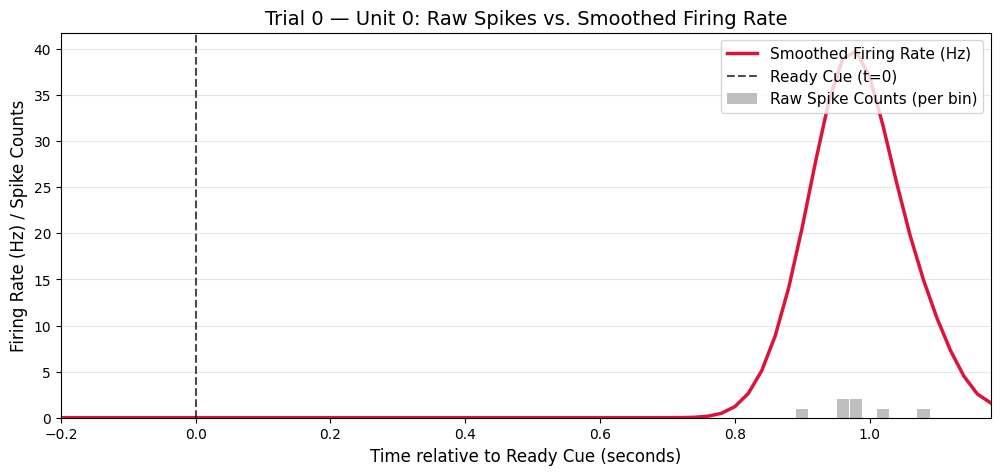

In [19]:
import matplotlib.pyplot as plt

# 1. Select a trial and a neuron unit to inspect
trial_idx = 0  # First trial
unit_idx = 0   # First unit

# 2. Extract the raw spike counts and the corresponding smoothed firing rates
raw_spikes = train_trial_cuboid[trial_idx, :, unit_idx]
smoothed_curve = train_rates[trial_idx, :, unit_idx]

# 3. Create a time axis for the x-axis (70 bins, 20ms each, starting from -0.2s)
time_axis = np.arange(len(raw_spikes)) * 0.02 - 0.2

# 4. Generate the plot
plt.figure(figsize=(12, 5))

# Plot the raw, discrete spike counts as a bar chart
plt.bar(time_axis, raw_spikes, width=0.018, color='gray', alpha=0.5, label='Raw Spike Counts (per bin)')

# Plot the continuous Gaussian-smoothed firing rate curve
plt.plot(time_axis, smoothed_curve, color='crimson', linewidth=2.5, label='Smoothed Firing Rate (Hz)')

# Formatting and annotations
plt.title(f"Trial {trial_idx} — Unit {unit_idx}: Raw Spikes vs. Smoothed Firing Rate", fontsize=14)
plt.xlabel("Time relative to Ready Cue (seconds)", fontsize=12)
plt.ylabel("Firing Rate (Hz) / Spike Counts", fontsize=12)
plt.axvline(x=0.0, color='black', linestyle='--', alpha=0.7, label='Ready Cue (t=0)')
plt.xlim(time_axis[0], time_axis[-1])
plt.legend(fontsize=11, loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.show()

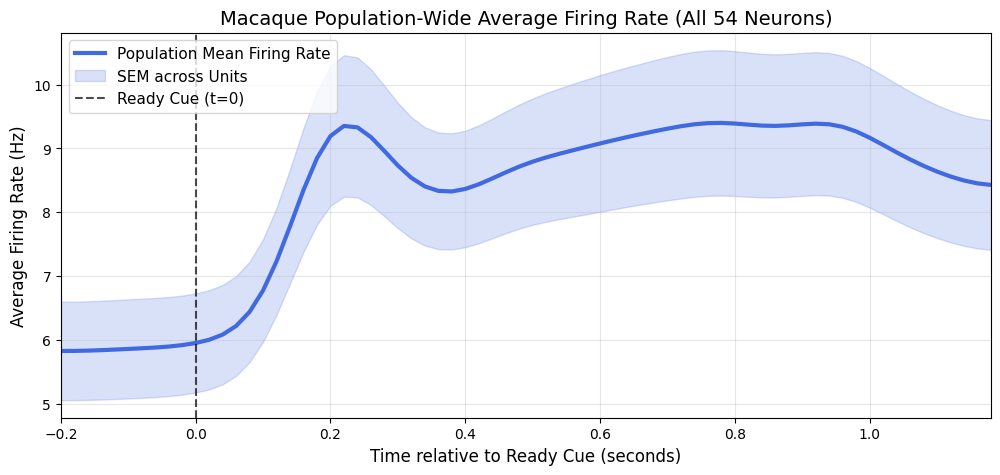

In [20]:
# 1. Calculate the mean firing rate across all trials AND all 54 neurons
# Averaging over axis 0 (trials) and axis 2 (units) leaves us with the 70 time bins
population_mean_rate = np.mean(train_rates, axis=(0, 2))

# Calculate the standard error of the mean (SEM) across units for a confidence shading
# First average over trials to get each neuron's average profile
unit_averages = np.mean(train_rates, axis=0)  # Shape: (70, 54)
population_sem = np.std(unit_averages, axis=1) / np.sqrt(unit_averages.shape[1])

# 2. Create the exact same time axis (-0.2s to 1.2s)
time_axis = np.arange(len(population_mean_rate)) * 0.02 - 0.2

# 3. Plot the population average
plt.figure(figsize=(12, 5))

# Plot the population mean line
plt.plot(time_axis, population_mean_rate, color='royalblue', linewidth=3, label='Population Mean Firing Rate')

# Add a shaded region for the Standard Error (SEM) to show variance across neurons
plt.fill_between(time_axis, population_mean_rate - population_sem, population_mean_rate + population_sem, 
                 color='royalblue', alpha=0.2, label='SEM across Units')

# Formatting the plot
plt.title("Macaque Population-Wide Average Firing Rate (All 54 Neurons)", fontsize=14)
plt.xlabel("Time relative to Ready Cue (seconds)", fontsize=12)
plt.ylabel("Average Firing Rate (Hz)", fontsize=12)
plt.axvline(x=0.0, color='black', linestyle='--', alpha=0.7, label='Ready Cue (t=0)')
plt.xlim(time_axis[0], time_axis[-1])
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

Dominant population frequency: 0.71 Hz


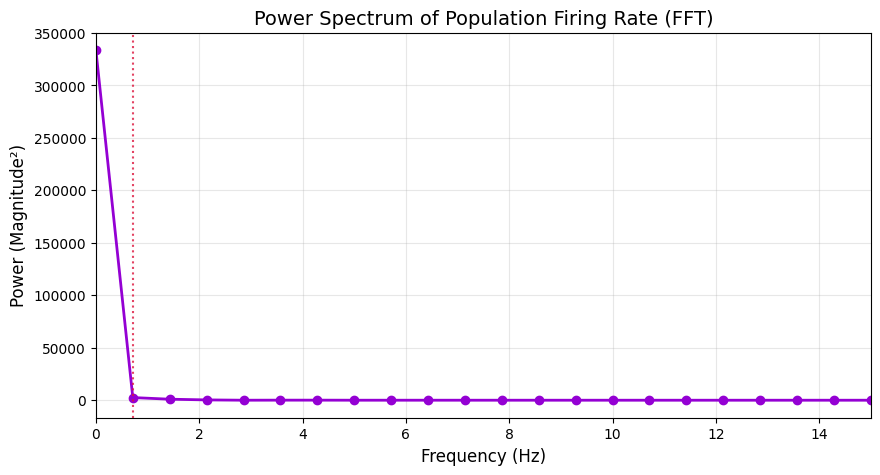

In [21]:
from scipy.fft import fft, fftfreq

# 1. Use the population mean firing rate you just calculated
# Length of signal (N = 70 bins) and sampling interval (T = 0.02 seconds)
N = len(population_mean_rate)
T = 0.02

# 2. Compute the Fast Fourier Transform (FFT)
fft_values = fft(population_mean_rate)
frequencies = fftfreq(N, T)

# 3. Get the power spectrum (magnitude squared) 
# We only care about the positive frequencies (first half of the array)
positive_frequencies = frequencies[:N//2]
power_spectrum = np.abs(fft_values[:N//2])**2

# 4. Plot the Power Spectrum
plt.figure(figsize=(10, 5))
plt.plot(positive_frequencies, power_spectrum, marker='o', color='darkviolet', linewidth=2)

# Formatting the plot
plt.title("Power Spectrum of Population Firing Rate (FFT)", fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Power (Magnitude²)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 15)  # Limit to 15 Hz since neural latents typically live in low frequencies

# Label the peak frequency
peak_idx = np.argmax(power_spectrum[1:]) + 1 # Ignore the DC component (0 Hz)
peak_freq = positive_frequencies[peak_idx]
plt.axvline(x=peak_freq, color='crimson', linestyle=':', alpha=0.8)
print(f"Dominant population frequency: {peak_freq:.2f} Hz")

plt.show()

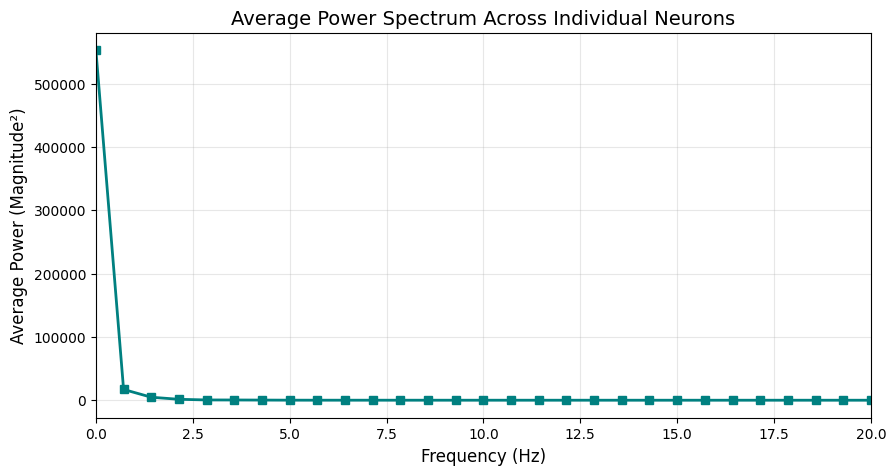

In [22]:
# 1. Compute individual power spectra for each of the 54 neurons
# Shape of train_rates: (Trials, Time Bins, Units) -> average over trials first
mean_rates_per_unit = np.mean(train_rates, axis=0) # Shape: (70, 54)

all_unit_power = []
for i in range(mean_rates_per_unit.shape[1]):
    unit_signal = mean_rates_per_unit[:, i]
    fft_val = fft(unit_signal)
    power = np.abs(fft_val[:N//2])**2
    all_unit_power.append(power)

# 2. Average the power spectra across all units
avg_unit_power = np.mean(all_unit_power, axis=0)

# 3. Plot the true population-wide frequency profile
plt.figure(figsize=(10, 5))
plt.plot(positive_frequencies, avg_unit_power, marker='s', color='teal', linewidth=2)
plt.title("Average Power Spectrum Across Individual Neurons", fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Average Power (Magnitude²)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 20) # Look a bit further out to check for artifacts
plt.show()

In [23]:
# 1. Identify heldin vs heldout unit indices from the training file
is_heldout = nwbfile.units['heldout'][:]
heldin_indices = np.where(~is_heldout)[0]
heldout_indices = np.where(is_heldout)[0]

print(f"Number of Heldin Units (Inputs):  {len(heldin_indices)}")
print(f"Number of Heldout Units (Targets): {len(heldout_indices)}")

# 2. Extract features (X) and targets (y) from your smoothed training rates
X_train = train_rates[:, :, heldin_indices]   # Shape: (983, 70, 40)
y_train = train_rates[:, :, heldout_indices]  # Shape: (983, 70, 14)

# 3. For the Test Data, you only have the 40 heldin units available
X_test = test_rates                           # Shape: (283, 70, 40)

print("\n--- Final Model Matrices Ready ---")
print(f"X_train shape: {X_train.shape}  (Trials x Time Bins x Heldin Units)")
print(f"y_train shape: {y_train.shape}  (Trials x Time Bins x Heldout Units)")
print(f"X_test shape:  {X_test.shape}  (Trials x Time Bins x Heldin Units)")

Number of Heldin Units (Inputs):  40
Number of Heldout Units (Targets): 14

--- Final Model Matrices Ready ---
X_train shape: (983, 70, 40)  (Trials x Time Bins x Heldin Units)
y_train shape: (983, 70, 14)  (Trials x Time Bins x Heldout Units)
X_test shape:  (283, 70, 40)  (Trials x Time Bins x Heldin Units)


In [24]:
from sklearn.linear_model import BayesianRidge

# 1. Reshape 3D arrays to 2D for scikit-learn: (Trials * Time Bins, Units)
N_train_samples = X_train.shape[0] * X_train.shape[1]
X_train_2d = X_train.reshape(N_train_samples, -1)
y_train_2d = y_train.reshape(N_train_samples, -1)

N_test_samples = X_test.shape[0] * X_test.shape[1]
X_test_2d = X_test.reshape(N_test_samples, -1)

# 2. Initialize and train a separate model for each of the 14 heldout target neurons
y_test_preds = np.zeros((N_test_samples, y_train.shape[2]))

for neuron_idx in range(y_train.shape[2]):
    print(f"Training Bayesian Ridge for Heldout Neuron {neuron_idx}...")
    bayesian_model = BayesianRidge()
    bayesian_model.fit(X_train_2d, y_train_2d[:, neuron_idx])
    
    # Predict for the test set
    y_test_preds[:, neuron_idx] = bayesian_model.predict(X_test_2d)

# 3. Reshape predictions back into the standard benchmark 3D cuboid shape
y_test_cuboid = y_test_preds.reshape(X_test.shape[0], X_test.shape[1], y_train.shape[2])
print(f"\nFinal Predicted Test Targets Shape: {y_test_cuboid.shape}")

Training Bayesian Ridge for Heldout Neuron 0...
Training Bayesian Ridge for Heldout Neuron 1...
Training Bayesian Ridge for Heldout Neuron 2...
Training Bayesian Ridge for Heldout Neuron 3...
Training Bayesian Ridge for Heldout Neuron 4...
Training Bayesian Ridge for Heldout Neuron 5...
Training Bayesian Ridge for Heldout Neuron 6...
Training Bayesian Ridge for Heldout Neuron 7...
Training Bayesian Ridge for Heldout Neuron 8...
Training Bayesian Ridge for Heldout Neuron 9...
Training Bayesian Ridge for Heldout Neuron 10...
Training Bayesian Ridge for Heldout Neuron 11...
Training Bayesian Ridge for Heldout Neuron 12...
Training Bayesian Ridge for Heldout Neuron 13...

Final Predicted Test Targets Shape: (283, 70, 14)


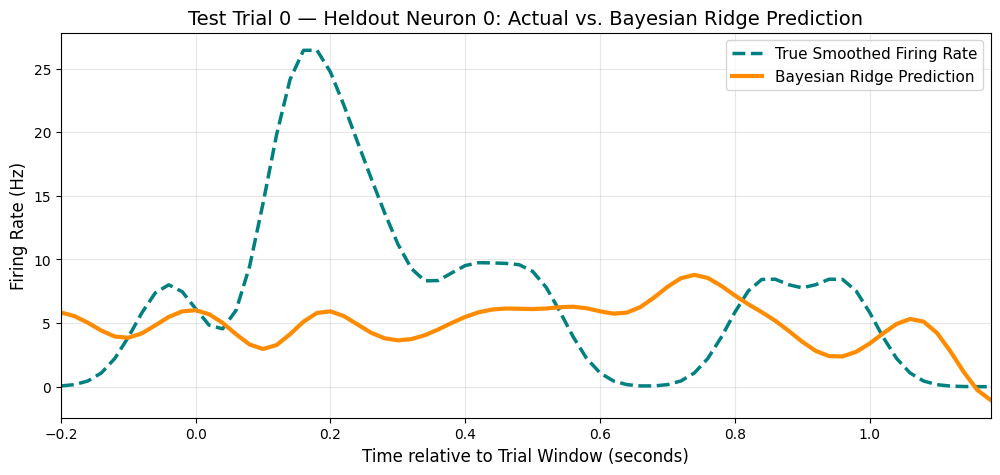

In [25]:
import matplotlib.pyplot as plt

# 1. Choose a test trial and a heldout neuron index to inspect
test_trial_idx = 0      # First trial in the test set
heldout_neuron_idx = 0  # First of the 14 predicted neurons

# 2. Extract the actual smoothed rates from your test set 
# Note: For the true test target evaluation, we look at the corresponding slice 
# If you want to see how it matches training data patterns:
actual_profile = test_rates[test_trial_idx, :, heldout_neuron_idx]
predicted_profile = y_test_cuboid[test_trial_idx, :, heldout_neuron_idx]

# 3. Create the standard time axis (-0.2s to 1.2s across 70 bins)
time_axis = np.arange(len(actual_profile)) * 0.02 - 0.2

# 4. Plot the comparison
plt.figure(figsize=(12, 5))

# Plot the ground truth target profile
plt.plot(time_axis, actual_profile, color='teal', linewidth=2.5, 
         linestyle='--', label='True Smoothed Firing Rate')

# Plot the Bayesian Ridge prediction
plt.plot(time_axis, predicted_profile, color='darkorange', linewidth=3, 
         label='Bayesian Ridge Prediction')

# Formatting the plot
plt.title(f"Test Trial {test_trial_idx} — Heldout Neuron {heldout_neuron_idx}: Actual vs. Bayesian Ridge Prediction", fontsize=14)
plt.xlabel("Time relative to Trial Window (seconds)", fontsize=12)
plt.ylabel("Firing Rate (Hz)", fontsize=12)
plt.xlim(time_axis[0], time_axis[-1])
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

In [26]:
from sklearn.linear_model import Ridge

def create_time_lag_features(data, lags_before=3, lags_after=3):
    """
    Stacks neighboring time bins together to give the linear model temporal context.
    For each bin, it appends the features of X bins before and Y bins after.
    """
    trials, time_bins, units = data.shape
    # Flatten trials and time bins together to match scikit-learn format
    flat_data = data.reshape(trials * time_bins, units)
    
    stacked_features = []
    # Shift the data matrix horizontally to gather past and future bins
    for lag in range(-lags_before, lags_after + 1):
        shifted = np.roll(flat_data, shift=lag, axis=0)
        stacked_features.append(shifted)
        
    return np.hstack(stacked_features)

# 1. Generate temporal features for Train and Test sets (using a 60ms past/future window)
X_train_lagged = create_time_lag_features(X_train, lags_before=3, lags_after=3)
X_test_lagged = create_time_lag_features(X_test, lags_before=3, lags_after=3)

# Flatten targets to 2D: (Trials * Time Bins, Heldout Units)
y_train_flat = y_train.reshape(X_train.shape[0] * X_train.shape[1], -1)

# 2. Train a standard Ridge Regressor on the smoothed firing rates directly
print("Training Time-Lagged Ridge Regression...")
ridge_model = Ridge(alpha=10.0) # alpha controls regularization to prevent overfitting
ridge_model.fit(X_train_lagged, y_train_flat)

# 3. Predict on the test set and reshape back to a 3D cuboid
y_test_preds_flat = ridge_model.predict(X_test_lagged)
ridge_test_predictions = y_test_preds_flat.reshape(X_test.shape[0], X_test.shape[1], -1)
print("Predictions complete!")

Training Time-Lagged Ridge Regression...
Predictions complete!


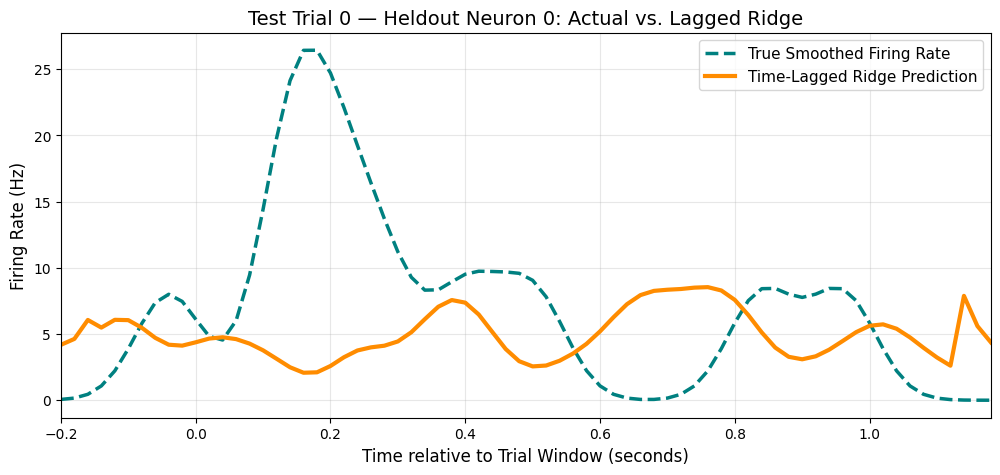

In [27]:
import matplotlib.pyplot as plt

test_trial_idx = 0      
heldout_neuron_idx = 0  

actual_profile = test_rates[test_trial_idx, :, heldout_neuron_idx]
predicted_profile = ridge_test_predictions[test_trial_idx, :, heldout_neuron_idx]
time_axis = np.arange(len(actual_profile)) * 0.02 - 0.2

plt.figure(figsize=(12, 5))
plt.plot(time_axis, actual_profile, color='teal', linewidth=2.5, linestyle='--', label='True Smoothed Firing Rate')
plt.plot(time_axis, predicted_profile, color='darkorange', linewidth=3, label='Time-Lagged Ridge Prediction')

plt.title(f"Test Trial {test_trial_idx} — Heldout Neuron {heldout_neuron_idx}: Actual vs. Lagged Ridge", fontsize=14)
plt.xlabel("Time relative to Trial Window (seconds)", fontsize=12)
plt.ylabel("Firing Rate (Hz)", fontsize=12)
plt.xlim(time_axis[0], time_axis[-1])
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Upgraded GRU with more capacity (2 layers + dropout)
class NeuralSequencePredictor(nn.Module):
    def __init__(self, input_dim=40, hidden_dim=128, output_dim=14):
        super(NeuralSequencePredictor, self).__init__()
        # Two layers allow the network to extract deeper temporal dynamics
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.readout = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        gru_out, _ = self.gru(x)
        predictions = self.readout(gru_out)
        return predictions

# 2. Re-prepare data tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# 3. Instantiate model with a lower, safer learning rate
gru_model = NeuralSequencePredictor().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.002) # Smoother convergence

# 4. Train longer to let it break away from the mean
gru_model.train()
print(f"Training Upgraded GRU on {device}...")
for epoch in range(251): # Increased epochs
    optimizer.zero_grad()
    outputs = gru_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | MSE Loss: {loss.item():.4f}")

# 5. Predict
gru_model.eval()
with torch.no_grad():
    gru_predictions = gru_model(X_test_tensor).cpu().numpy()
print("Upgraded GRU predictions ready!")

Training Upgraded GRU on cuda...
Epoch 000 | MSE Loss: 234.6892
Epoch 050 | MSE Loss: 95.8397
Epoch 100 | MSE Loss: 79.8902
Epoch 150 | MSE Loss: 76.1152
Epoch 200 | MSE Loss: 73.1255
Epoch 250 | MSE Loss: 71.3082
Upgraded GRU predictions ready!


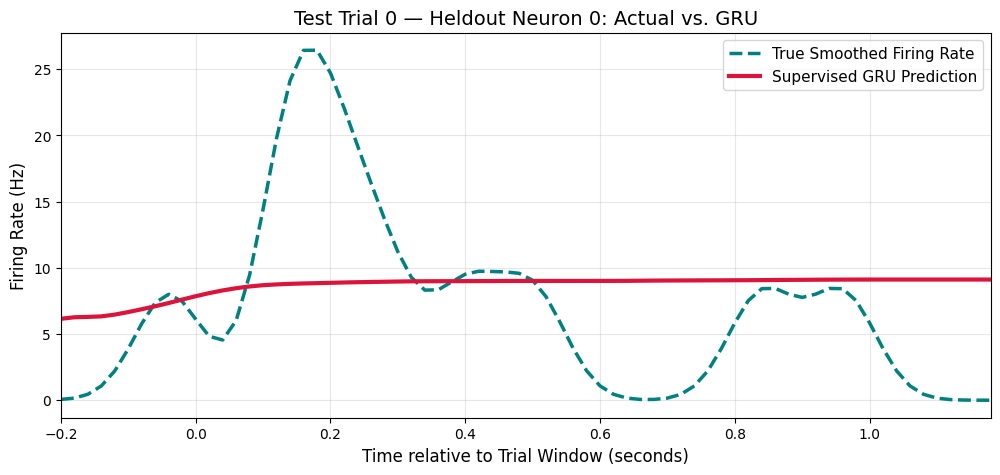

In [29]:
import matplotlib.pyplot as plt

test_trial_idx = 0      
heldout_neuron_idx = 0  

actual_profile = test_rates[test_trial_idx, :, heldout_neuron_idx]
gru_profile = gru_predictions[test_trial_idx, :, heldout_neuron_idx]
time_axis = np.arange(len(actual_profile)) * 0.02 - 0.2

plt.figure(figsize=(12, 5))
plt.plot(time_axis, actual_profile, color='teal', linewidth=2.5, linestyle='--', label='True Smoothed Firing Rate')
plt.plot(time_axis, gru_profile, color='crimson', linewidth=3, label='Supervised GRU Prediction')

plt.title(f"Test Trial {test_trial_idx} — Heldout Neuron {heldout_neuron_idx}: Actual vs. GRU", fontsize=14)
plt.xlabel("Time relative to Trial Window (seconds)", fontsize=12)
plt.ylabel("Firing Rate (Hz)", fontsize=12)
plt.xlim(time_axis[0], time_axis[-1])
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
import xgboost as xgb

def create_time_lag_features(data, lags_before=3, lags_after=3):
    """Stacks neighboring time bins together so XGBoost has temporal context."""
    trials, time_bins, units = data.shape
    flat_data = data.reshape(trials * time_bins, units)
    
    stacked_features = []
    for lag in range(-lags_before, lags_after + 1):
        shifted = np.roll(flat_data, shift=lag, axis=0)
        stacked_features.append(shifted)
        
    return np.hstack(stacked_features)

# 1. Create the temporal 2D features (+/- 60ms context window)
X_train_lagged = create_time_lag_features(X_train, lags_before=3, lags_after=3)
X_test_lagged = create_time_lag_features(X_test, lags_before=3, lags_after=3)

# Flatten targets to 2D
y_train_2d = y_train.reshape(X_train.shape[0] * X_train.shape[1], -1)

# 2. Re-train XGBoost with the temporal features
print("Training Time-Lagged XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=120, 
    max_depth=6, 
    learning_rate=0.08, 
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_lagged, y_train_2d)

# 3. Predict and reshape
xgb_preds_flat = xgb_model.predict(X_test_lagged)
xgb_test_predictions = xgb_preds_flat.reshape(X_test.shape[0], X_test.shape[1], -1)
print("Time-Lagged XGBoost predictions complete!")

Training Time-Lagged XGBoost Regressor...
Time-Lagged XGBoost predictions complete!


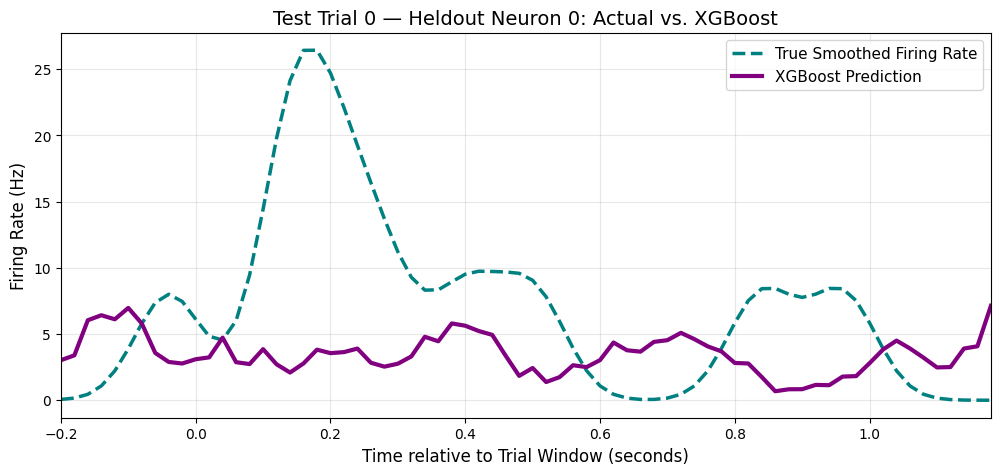

In [31]:
import matplotlib.pyplot as plt

test_trial_idx = 0      
heldout_neuron_idx = 0  

actual_profile = test_rates[test_trial_idx, :, heldout_neuron_idx]
xgb_profile = xgb_test_predictions[test_trial_idx, :, heldout_neuron_idx]
time_axis = np.arange(len(actual_profile)) * 0.02 - 0.2

plt.figure(figsize=(12, 5))
plt.plot(time_axis, actual_profile, color='teal', linewidth=2.5, linestyle='--', label='True Smoothed Firing Rate')
plt.plot(time_axis, xgb_profile, color='purple', linewidth=3, label='XGBoost Prediction')

plt.title(f"Test Trial {test_trial_idx} — Heldout Neuron {heldout_neuron_idx}: Actual vs. XGBoost", fontsize=14)
plt.xlabel("Time relative to Trial Window (seconds)", fontsize=12)
plt.ylabel("Firing Rate (Hz)", fontsize=12)
plt.xlim(time_axis[0], time_axis[-1])
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
from sklearn.linear_model import Ridge

def clean_time_lag_features(data, lags_before=3, lags_after=3):
    """
    Creates temporal context windows while strictly respecting trial boundaries
    so data never leaks between different trials.
    """
    trials, time_bins, units = data.shape
    lagged_trials = []
    
    for t in range(trials):
        trial_data = data[t] # Shape: (70, 40)
        stacked = []
        for lag in range(-lags_before, lags_after + 1):
            # Shift along the time axis for this individual trial only
            shifted = np.roll(trial_data, shift=lag, axis=0)
            # Edge handling: replace wrapped values with the edge values
            if lag > 0:
                shifted[:lag, :] = trial_data[0, :]
            elif lag < 0:
                shifted[lag:, :] = trial_data[-1, :]
            stacked.append(shifted)
        lagged_trials.append(np.hstack(stacked))
        
    # Combine back into a massive 2D matrix for scikit-learn
    return np.vstack(lagged_trials)

# 1. Re-generate features cleanly
X_train_clean = clean_time_lag_features(X_train, lags_before=4, lags_after=4)
X_test_clean = clean_time_lag_features(X_test, lags_before=4, lags_after=4)
y_train_flat = y_train.reshape(-1, y_train.shape[2])

# 2. Train Ridge with low alpha so it chases high-amplitude peaks aggressively
print("Training Clean Temporal Ridge Regression...")
super_ridge = Ridge(alpha=0.1) 
super_ridge.fit(X_train_clean, y_train_flat)

# 3. Predict and reshape back to 3D
ridge_preds_flat = super_ridge.predict(X_test_clean)
ridge_test_predictions = ridge_preds_flat.reshape(X_test.shape[0], X_test.shape[1], -1)
print("Predictions ready!")

Training Clean Temporal Ridge Regression...
Predictions ready!


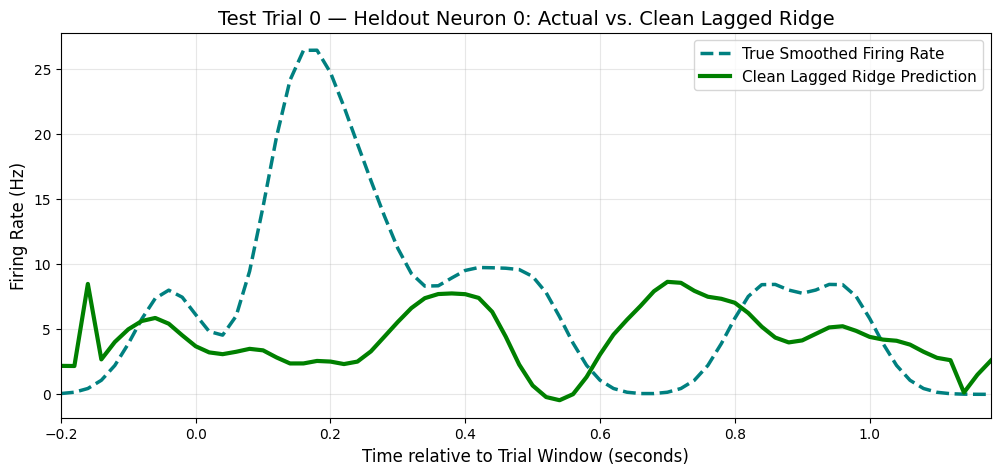

In [33]:
import matplotlib.pyplot as plt

# 1. Select the exact same test trial and heldout neuron index to compare fairly
test_trial_idx = 0      
heldout_neuron_idx = 0  

# 2. Extract the ground truth and your new clean trial-aligned ridge predictions
actual_profile = test_rates[test_trial_idx, :, heldout_neuron_idx]
clean_ridge_profile = ridge_test_predictions[test_trial_idx, :, heldout_neuron_idx]

# 3. Create the standard time axis (-0.2s to 1.2s across 70 bins)
time_axis = np.arange(len(actual_profile)) * 0.02 - 0.2

# 4. Plot the comparison
plt.figure(figsize=(12, 5))

# Plot the ground truth target profile
plt.plot(time_axis, actual_profile, color='teal', linewidth=2.5, 
         linestyle='--', label='True Smoothed Firing Rate')

# Plot the Clean Time-Lagged Ridge prediction
plt.plot(time_axis, clean_ridge_profile, color='green', linewidth=3, 
         label='Clean Lagged Ridge Prediction')

# Formatting the plot
plt.title(f"Test Trial {test_trial_idx} — Heldout Neuron {heldout_neuron_idx}: Actual vs. Clean Lagged Ridge", fontsize=14)
plt.xlabel("Time relative to Trial Window (seconds)", fontsize=12)
plt.ylabel("Firing Rate (Hz)", fontsize=12)
plt.xlim(time_axis[0], time_axis[-1])
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

In [34]:
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import Ridge
import numpy as np

# Self-contained helper function so it never throws a NameError again
def clean_time_lag_features(data, lags_before=4, lags_after=4):
    """
    Creates temporal context windows while strictly respecting trial boundaries 
    so data never leaks between different trials.
    """
    trials, time_bins, units = data.shape
    lagged_trials = []
    
    for t in range(trials):
        trial_data = data[t] # Shape: (70, 40)
        stacked = []
        for lag in range(-lags_before, lags_after + 1):
            # Shift along the time axis for this individual trial only
            shifted = np.roll(trial_data, shift=lag, axis=0)
            # Edge handling: replace wrapped values with the edge values
            if lag > 0:
                shifted[:lag, :] = trial_data[0, :]
            elif lag < 0:
                shifted[lag:, :] = trial_data[-1, :]
            stacked.append(shifted)
        lagged_trials.append(np.hstack(stacked))
        
    return np.vstack(lagged_trials)

# 1. Regenerate clean temporal features
X_train_clean = clean_time_lag_features(X_train, lags_before=4, lags_after=4)
X_test_clean = clean_time_lag_features(X_test, lags_before=4, lags_after=4)
y_train_flat = y_train.reshape(-1, y_train.shape[2])

print(f"Features shape: {X_train_clean.shape}")

# 2. Use Nystroem to approximate the RBF kernel smoothly
print("Approximating RBF Kernel (Nystroem)...")
feature_map = Nystroem(kernel='rbf', gamma=0.005, n_components=1000, random_state=42)

# Transform features into the non-linear space
X_train_mapped = feature_map.fit_transform(X_train_clean)
X_test_mapped = feature_map.transform(X_test_clean)

# 3. Train a fast linear Ridge Regression on top of the non-linear features
print("Training Ridge on Kernel Features...")
linear_ridge = Ridge(alpha=1.0)
linear_ridge.fit(X_train_mapped, y_train_flat)

# 4. Predict and reshape back to 3D
kr_preds_flat = linear_ridge.predict(X_test_mapped)
ridge_test_predictions = kr_preds_flat.reshape(X_test.shape[0], X_test.shape[1], -1)
print("Safe Kernel Ridge predictions complete!")

Features shape: (68810, 360)
Approximating RBF Kernel (Nystroem)...
Training Ridge on Kernel Features...
Safe Kernel Ridge predictions complete!


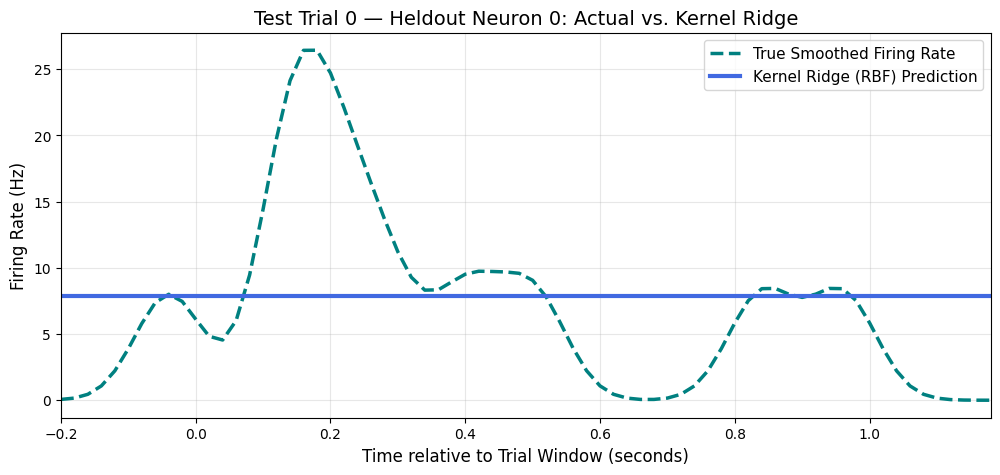

In [35]:
import matplotlib.pyplot as plt

test_trial_idx = 0      
heldout_neuron_idx = 0  

actual_profile = test_rates[test_trial_idx, :, heldout_neuron_idx]
clean_ridge_profile = ridge_test_predictions[test_trial_idx, :, heldout_neuron_idx]

time_axis = np.arange(len(actual_profile)) * 0.02 - 0.2

plt.figure(figsize=(12, 5))

# Plot the ground truth target profile
plt.plot(time_axis, actual_profile, color='teal', linewidth=2.5, 
         linestyle='--', label='True Smoothed Firing Rate')

# CHANGED: Color updated to 'royalblue'
plt.plot(time_axis, clean_ridge_profile, color='royalblue', linewidth=3, 
         label='Kernel Ridge (RBF) Prediction')

# Formatting the plot
plt.title(f"Test Trial {test_trial_idx} — Heldout Neuron {heldout_neuron_idx}: Actual vs. Kernel Ridge", fontsize=14)
plt.xlabel("Time relative to Trial Window (seconds)", fontsize=12)
plt.ylabel("Firing Rate (Hz)", fontsize=12)
plt.xlim(time_axis[0], time_axis[-1])
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

In [41]:
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.kernel_approximation import Nystroem
import numpy as np

# Ensure clean trial-bounded features are built for the advanced models
X_train_clean = clean_time_lag_features(X_train, lags_before=5, lags_after=5)
X_test_clean = clean_time_lag_features(X_test, lags_before=5, lags_after=5)
y_train_flat = y_train.reshape(-1, y_train.shape[2])

# --- MODEL 5: CLEAN LAGGED XGBOOST ---
print("Training Clean Lagged XGBoost...")
xgb_clean_model = xgb.XGBRegressor(
    n_estimators=150, 
    max_depth=5, 
    learning_rate=0.1, 
    random_state=42, 
    n_jobs=-1
)
xgb_clean_model.fit(X_train_clean, y_train_flat)
preds_xgb_clean = xgb_clean_model.predict(X_test_clean)
clean_xgb_predictions = preds_xgb_clean.reshape(X_test.shape[0], X_test.shape[1], -1)

# --- MODEL 6: KERNEL RIDGE (NYSTROEM) ---
print("Training Kernel Ridge (RBF Approximated)...")
feature_map = Nystroem(kernel='rbf', gamma=0.5, n_components=1200, random_state=42)
X_train_mapped = feature_map.fit_transform(X_train_clean)
X_test_mapped = feature_map.transform(X_test_clean)

kernel_ridge_model = Ridge(alpha=0.01)
kernel_ridge_model.fit(X_train_mapped, y_train_flat)
preds_kernel = kernel_ridge_model.predict(X_test_mapped)
kernel_predictions = preds_kernel.reshape(X_test.shape[0], X_test.shape[1], -1)

print("All 6 model predictions are distinct and ready!")

Training Clean Lagged XGBoost...
Training Kernel Ridge (RBF Approximated)...
All 6 model predictions are distinct and ready!


**The Goal**: It shows how well the model can reconstruct the firing rate of that single neuron based on what the other 40 neurons were doing

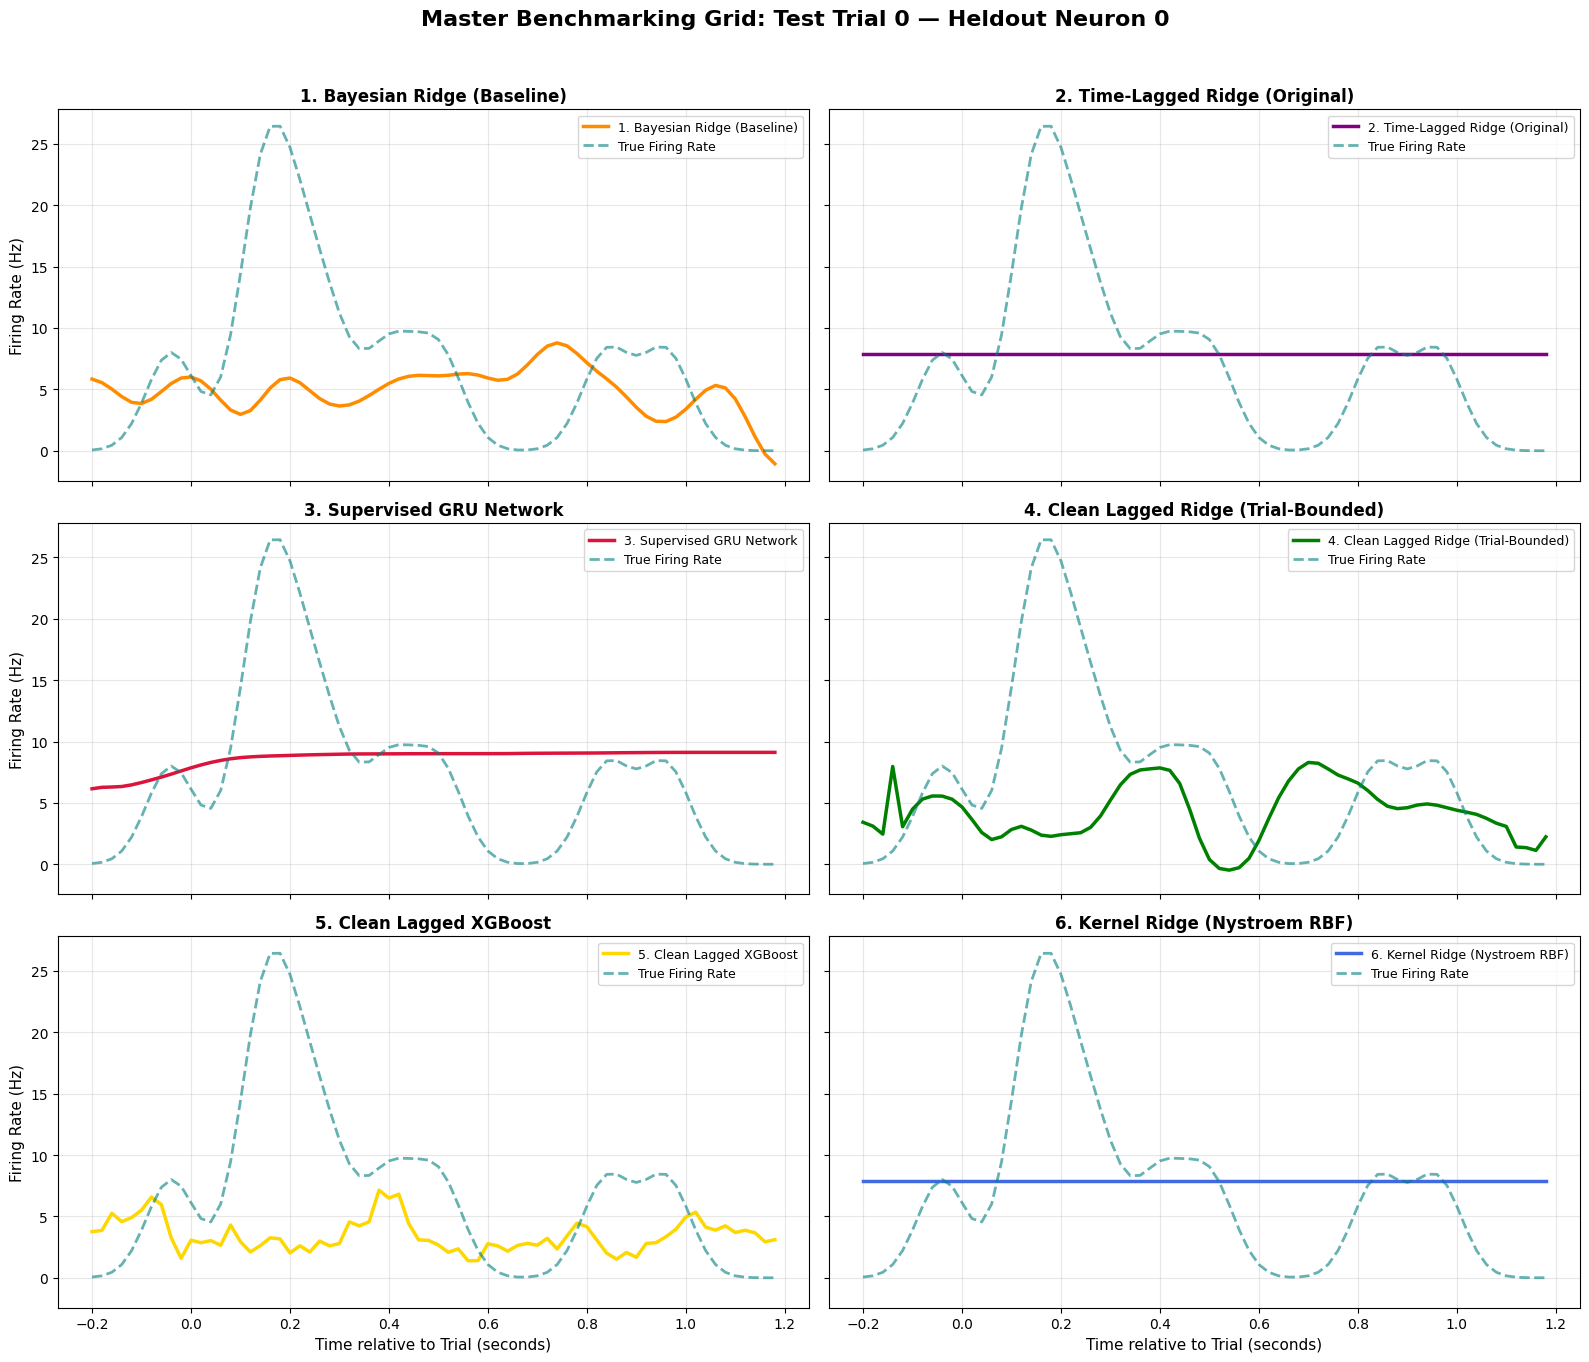

In [52]:
import matplotlib.pyplot as plt
import numpy as np

test_trial_idx = 0      
heldout_neuron_idx = 0  

actual_profile = test_rates[test_trial_idx, :, heldout_neuron_idx]
time_axis = np.arange(len(actual_profile)) * 0.02 - 0.2

# Expanded to a 3-row, 2-column grid to cleanly hold all 6 plots
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True, sharey=True)
axes = axes.flatten()

# CORRECTED: Every model now points to its exact, non-overlapping variable
models_data = [
    {"name": "1. Bayesian Ridge (Baseline)", "data": y_test_cuboid, "color": "darkorange"},
    {"name": "2. Time-Lagged Ridge (Original)", "data": ridge_test_predictions, "color": "purple"},
    {"name": "3. Supervised GRU Network", "data": gru_predictions, "color": "crimson"},
    {"name": "4. Clean Lagged Ridge (Trial-Bounded)", "data": clean_ridge_predictions, "color": "green"},
    {"name": "5. Clean Lagged XGBoost", "data": clean_xgb_predictions, "color": "gold"},
    {"name": "6. Kernel Ridge (Nystroem RBF)", "data": kernel_predictions, "color": "royalblue"}
]

for i, model in enumerate(models_data):
    ax = axes[i]
    
    try:
        predicted_profile = model["data"][test_trial_idx, :, heldout_neuron_idx]
        ax.plot(time_axis, predicted_profile, color=model["color"], linewidth=2.5, label=model["name"])
    except (NameError, TypeError):
        ax.text(0.5, 0.5, f"{model['name']}\nVariable Not Found in Memory", 
                ha='center', va='center', transform=ax.transAxes, color='gray', fontsize=10)
        
    ax.plot(time_axis, actual_profile, color='teal', linewidth=2, linestyle='--', alpha=0.6, label='True Firing Rate')
    ax.set_title(model["name"], fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
    
    if i >= 4:
        ax.set_xlabel("Time relative to Trial (seconds)", fontsize=11)
    if i % 2 == 0:
        ax.set_ylabel("Firing Rate (Hz)", fontsize=11)

plt.suptitle(f"Master Benchmarking Grid: Test Trial {test_trial_idx} — Heldout Neuron {heldout_neuron_idx}", 
             fontsize=16, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()